In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

customers = pd.read_csv('/content/customers.csv')
products = pd.read_csv('/content/products.csv')
orders = pd.read_csv('/content/orders.csv')
order_items = pd.read_csv('/content/order_items.csv')
payments = pd.read_csv('/content/payments.csv')
returns = pd.read_csv('/content/returns.csv')

print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Returns:", returns.shape)

Customers: (15000, 11)
Products: (1500, 10)
Orders: (45000, 12)
Order Items: (92002, 11)
Payments: (45000, 8)
Returns: (5416, 8)


# E-commerce Revenue, Customer & Product Analytics

## Python Exploratory Data Analysis

This notebook extends the SQL analysis using Python and Pandas to explore sales trends, profitability, customer behavior, discount impact, and product returns.

### Analysis Objectives
- Validate and prepare the analytical datasets
- Explore revenue and profitability patterns
- Analyze the relationship between discounts and profit
- Investigate customer purchasing behavior
- Identify product and return-risk patterns
- Generate business-focused visualizations and insights

In [ ]:
# Display basic information for each dataset

datasets = {
    'Customers': customers,
    'Products': products,
    'Orders': orders,
    'Order Items': order_items,
    'Payments': payments,
    'Returns': returns
}

for name, df in datasets.items():
    print(f"\n{'=' * 50}")
    print(name)
    print('=' * 50)

    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0])


Customers
Rows: 15,000
Columns: 11

Data Types:
customer_id             int64
first_name             object
last_name              object
gender                 object
age                     int64
city                   object
country                object
signup_date            object
customer_type          object
acquisition_channel    object
marketing_source       object
dtype: object

Missing Values:
marketing_source    120
dtype: int64

Products
Rows: 1,500
Columns: 10

Data Types:
product_id          int64
product_name       object
category           object
subcategory        object
brand              object
supplier           object
unit_cost         float64
list_price        float64
launch_date        object
product_status     object
dtype: object

Missing Values:
Series([], dtype: int64)

Orders
Rows: 45,000
Columns: 12

Data Types:
order_id              int64
customer_id           int64
order_date           object
order_status         object
sales_channel        object
ship

In [ ]:
print("Duplicate rows")
print("-" * 40)

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum():,}")

Duplicate rows
----------------------------------------
Customers: 0
Products: 0
Orders: 0
Order Items: 0
Payments: 0
Returns: 0


In [ ]:
# Convert date columns to datetime

customers['signup_date'] = pd.to_datetime(customers['signup_date'])

products['launch_date'] = pd.to_datetime(products['launch_date'])

orders['order_date'] = pd.to_datetime(orders['order_date'])

payments['payment_date'] = pd.to_datetime(payments['payment_date'])

returns['return_date'] = pd.to_datetime(returns['return_date'])

print("Date columns converted successfully.")

Date columns converted successfully.


In [ ]:
print("Order date range:")
print(orders['order_date'].min(), "to", orders['order_date'].max())

print("\nReturn date range:")
print(returns['return_date'].min(), "to", returns['return_date'].max())

Order date range:
2023-01-01 00:00:00 to 2025-12-31 00:00:00

Return date range:
2023-01-07 00:00:00 to 2026-01-29 00:00:00


In [ ]:
# Keep only completed orders
completed_orders = orders[
    orders['order_status'] == 'Completed'
].copy()

print("Completed Orders:", completed_orders.shape[0])

Completed Orders: 43001


In [ ]:
sales = completed_orders.merge(
    order_items,
    on='order_id',
    how='inner',
    suffixes=('_order', '_item')
)

print("Sales rows:", sales.shape)

Sales rows: (87940, 22)


In [ ]:
sales = sales.merge(
    products,
    on='product_id',
    how='left'
)

print("After product merge:", sales.shape)

After product merge: (87940, 31)


In [ ]:
print("Unique Orders:", sales['order_id'].nunique())
print("Unique Customers:", sales['customer_id'].nunique())
print("Unique Products:", sales['product_id'].nunique())

print("\nRevenue:", round(sales['revenue'].sum(), 2))
print("Gross Profit:", round(sales['profit'].sum(), 2))
print("Units Sold:", sales['quantity'].sum())

Unique Orders: 43001
Unique Customers: 11279
Unique Products: 1500

Revenue: 19602501.46
Gross Profit: 4863101.78
Units Sold: 123654


In [ ]:
# Time-based features
sales['year'] = sales['order_date'].dt.year
sales['month'] = sales['order_date'].dt.month
sales['month_name'] = sales['order_date'].dt.month_name()
sales['year_month'] = sales['order_date'].dt.to_period('M').astype(str)

# Profitability
sales['gross_margin_pct'] = np.where(
    sales['revenue'] != 0,
    (sales['profit'] / sales['revenue']) * 100,
    np.nan
)

# Discount percentage for easier interpretation
sales['discount_pct_display'] = sales['discount_pct'] * 100

# Identify loss-making transactions
sales['is_loss_making'] = sales['profit'] < 0

print(sales[
    [
        'order_id',
        'order_date',
        'year_month',
        'revenue',
        'profit',
        'gross_margin_pct',
        'discount_pct_display',
        'is_loss_making'
    ]
].head())

   order_id order_date year_month  revenue  profit  gross_margin_pct  \
0    300001 2024-05-26    2024-05   111.30   37.12         33.351303   
1    300001 2024-05-26    2024-05    60.51   18.06         29.846306   
2    300001 2024-05-26    2024-05   333.79    7.97          2.387729   
3    300002 2023-09-03    2023-09    22.39    9.99         44.618133   
4    300003 2025-02-26    2025-02   318.57   66.67         20.927897   

   discount_pct_display  is_loss_making  
0                  20.0           False  
1                  20.0           False  
2                  20.0           False  
3                   0.0           False  
4                   0.0           False  


In [ ]:
print("Years:", sorted(sales['year'].unique()))
print("Average Discount %:", round(sales['discount_pct_display'].mean(), 2))
print("Loss-Making Lines:", sales['is_loss_making'].sum())

Years: [np.int32(2023), np.int32(2024), np.int32(2025)]
Average Discount %: 6.02
Loss-Making Lines: 1113


In [ ]:
discount_analysis = (
    sales.groupby('discount_pct_display', as_index=False)
    .agg(
        transactions=('order_item_id', 'count'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum')
    )
)

discount_analysis['margin_pct'] = (
    discount_analysis['profit'] /
    discount_analysis['revenue'] * 100
)

discount_analysis.head(10)

,discount_pct_display,transactions,revenue,profit,margin_pct
0,0.0,47347,11549579.72,3320951.04,28.753869
1,5.0,7941,1643730.15,436382.08,26.548280
2,10.0,11686,2382679.04,521332.94,21.880116
3,15.0,10481,2148312.43,353489.04,16.454266
4,20.0,9596,1812571.19,213716.83,11.790810
5,25.0,584,43790.60,12516.34,28.582253
6,30.0,305,21838.33,4713.51,21.583656


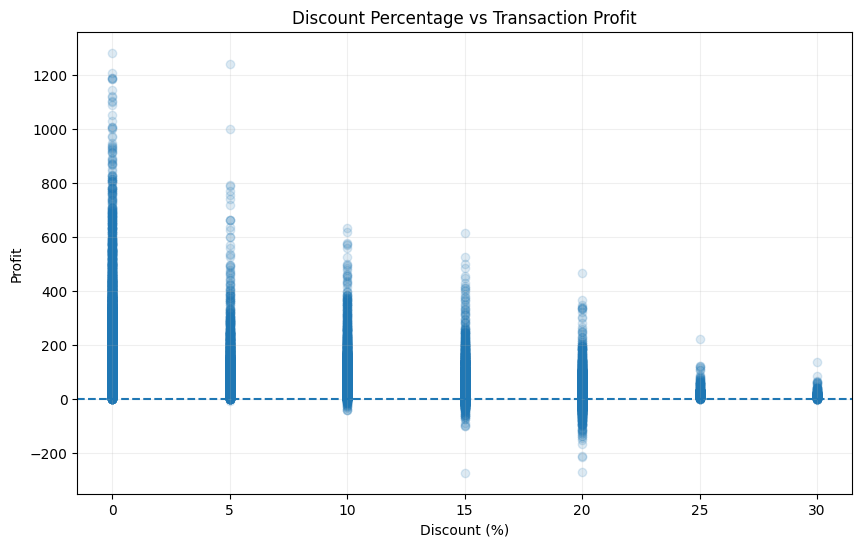

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    sales['discount_pct_display'],
    sales['profit'],
    alpha=0.15
)

plt.axhline(0, linestyle='--')

plt.title('Discount Percentage vs Transaction Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Profit')
plt.grid(alpha=0.2)

plt.show()

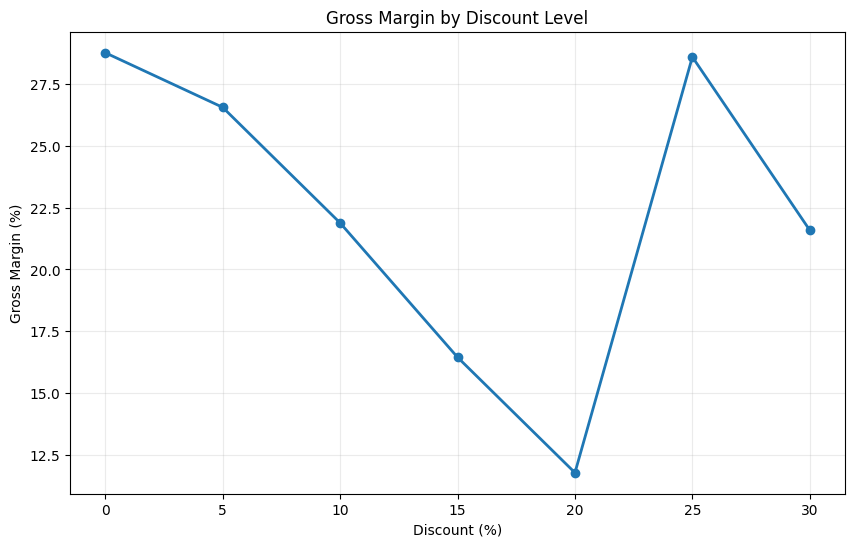

In [ ]:
discount_margin = (
    sales.groupby('discount_pct_display', as_index=False)
    .agg(
        transactions=('order_item_id', 'count'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum')
    )
)

discount_margin['margin_pct'] = (
    discount_margin['profit'] /
    discount_margin['revenue'] * 100
)

plt.figure(figsize=(10, 6))

plt.plot(
    discount_margin['discount_pct_display'],
    discount_margin['margin_pct'],
    marker='o',
    linewidth=2
)

plt.title('Gross Margin by Discount Level')
plt.xlabel('Discount (%)')
plt.ylabel('Gross Margin (%)')

plt.grid(alpha=0.25)

plt.show()

In [ ]:
correlation = sales[
    ['discount_pct_display', 'profit']
].corr()

correlation

,discount_pct_display,profit
discount_pct_display,1.000000,-0.246476
profit,-0.246476,1.000000


In [ ]:
sales.groupby('is_loss_making').agg(
    transactions=('order_item_id', 'count'),
    avg_discount=('discount_pct_display', 'mean'),
    avg_profit=('profit', 'mean'),
    avg_revenue=('revenue', 'mean')
).round(2)

,transactions,avg_discount,avg_profit,avg_revenue
is_loss_making,,,,
False,86827,5.86,56.28,219.13
True,1113,18.31,-21.36,517.93


In [ ]:
customer_behavior = (
    completed_orders.groupby('customer_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max')
    )
    .reset_index()
)

customer_revenue = (
    sales.groupby('customer_id', as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
        units_purchased=('quantity', 'sum')
    )
)

customer_behavior = customer_behavior.merge(
    customer_revenue,
    on='customer_id',
    how='left'
)

customer_behavior['avg_order_value'] = (
    customer_behavior['total_revenue'] /
    customer_behavior['total_orders']
)

customer_behavior.head()

,customer_id,total_orders,first_order,last_order,total_revenue,total_profit,units_purchased,avg_order_value
0,100001,25,2023-03-31,2025-11-25,19246.07,4763.53,84,769.842800
1,100002,2,2024-10-22,2025-12-11,1410.32,295.32,7,705.160000
2,100004,2,2024-09-10,2025-03-20,878.84,306.59,5,439.420000
3,100005,2,2024-02-23,2024-04-05,402.81,93.91,4,201.405000
4,100006,13,2023-01-07,2025-10-30,4349.85,1299.59,37,334.603846


In [ ]:
customer_behavior[
    [
        'total_orders',
        'total_revenue',
        'total_profit',
        'units_purchased',
        'avg_order_value'
    ]
].describe().round(2)

,total_orders,total_revenue,total_profit,units_purchased,avg_order_value
count,11279.00,11279.00,11279.00,11279.00,11279.00
mean,3.81,1737.96,431.16,10.96,456.17
std,4.39,2257.53,549.49,13.07,385.65
min,1.00,10.97,-86.23,1.00,10.97
25%,1.00,391.57,107.06,3.00,210.85
50%,2.00,1025.58,259.01,7.00,377.22
75%,5.00,2219.27,551.31,14.00,582.34
max,84.00,43769.57,10510.57,252.00,8024.40


In [ ]:
print(
    "Median Orders per Customer:",
    customer_behavior['total_orders'].median()
)

print(
    "Median Customer Revenue:",
    round(customer_behavior['total_revenue'].median(), 2)
)

print(
    "Mean Customer Revenue:",
    round(customer_behavior['total_revenue'].mean(), 2)
)

print(
    "90th Percentile Customer Revenue:",
    round(customer_behavior['total_revenue'].quantile(0.90), 2)
)

print(
    "95th Percentile Customer Revenue:",
    round(customer_behavior['total_revenue'].quantile(0.95), 2)
)

Median Orders per Customer: 2.0
Median Customer Revenue: 1025.58
Mean Customer Revenue: 1737.96
90th Percentile Customer Revenue: 4183.57
95th Percentile Customer Revenue: 5690.09


In [ ]:
print("Median Orders per Customer:",
      customer_behavior['total_orders'].median())

print("Median Customer Revenue:",
      round(customer_behavior['total_revenue'].median(), 2))

print("Mean Customer Revenue:",
      round(customer_behavior['total_revenue'].mean(), 2))

print("90th Percentile Customer Revenue:",
      round(customer_behavior['total_revenue'].quantile(0.90), 2))

print("95th Percentile Customer Revenue:",
      round(customer_behavior['total_revenue'].quantile(0.95), 2))

Median Orders per Customer: 2.0
Median Customer Revenue: 1025.58
Mean Customer Revenue: 1737.96
90th Percentile Customer Revenue: 4183.57
95th Percentile Customer Revenue: 5690.09


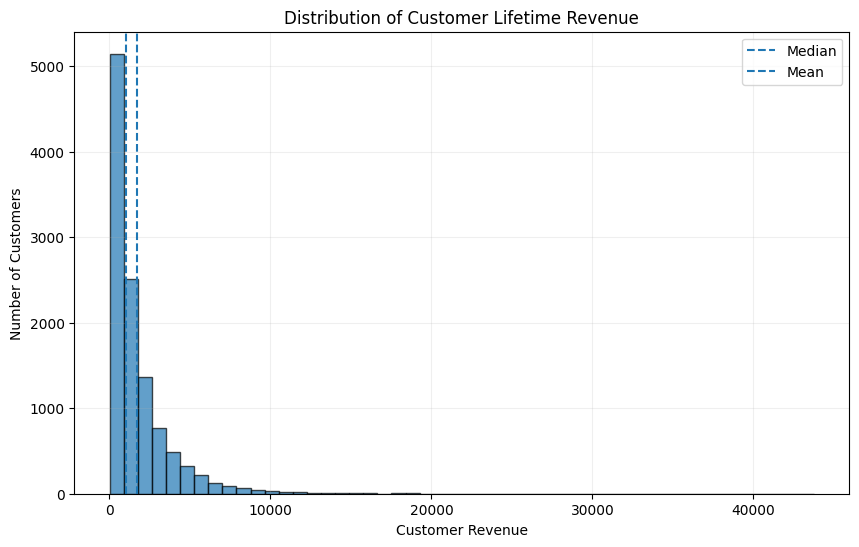

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_behavior['total_revenue'],
    bins=50,
    edgecolor='black',
    alpha=0.7
)

plt.axvline(
    customer_behavior['total_revenue'].median(),
    linestyle='--',
    label='Median'
)

plt.axvline(
    customer_behavior['total_revenue'].mean(),
    linestyle='--',
    label='Mean'
)

plt.title('Distribution of Customer Lifetime Revenue')
plt.xlabel('Customer Revenue')
plt.ylabel('Number of Customers')

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
frequency_analysis = (
    customer_behavior
    .groupby('total_orders')
    .agg(
        customers=('customer_id', 'count'),
        avg_revenue=('total_revenue', 'mean'),
        median_revenue=('total_revenue', 'median'),
        avg_profit=('total_profit', 'mean')
    )
    .reset_index()
)

frequency_analysis.head(10).round(2)

,total_orders,customers,avg_revenue,median_revenue,avg_profit
0,1,3382,462.02,270.41,114.04
1,2,2397,897.98,701.79,225.81
2,3,1533,1359.04,1158.84,340.27
3,4,1059,1862.21,1628.28,454.78
4,5,704,2261.00,2006.50,563.31
5,6,519,2620.96,2385.22,645.95
6,7,368,3207.00,2862.08,798.23
7,8,273,3732.94,3364.13,935.34
8,9,225,4114.06,4007.61,1013.29
9,10,178,4640.21,4400.36,1160.80


In [ ]:
frequency_correlation = customer_behavior[
    ['total_orders', 'total_revenue', 'total_profit']
].corr()

frequency_correlation.round(3)

,total_orders,total_revenue,total_profit
total_orders,1.000,0.888,0.901
total_revenue,0.888,1.000,0.971
total_profit,0.901,0.971,1.000


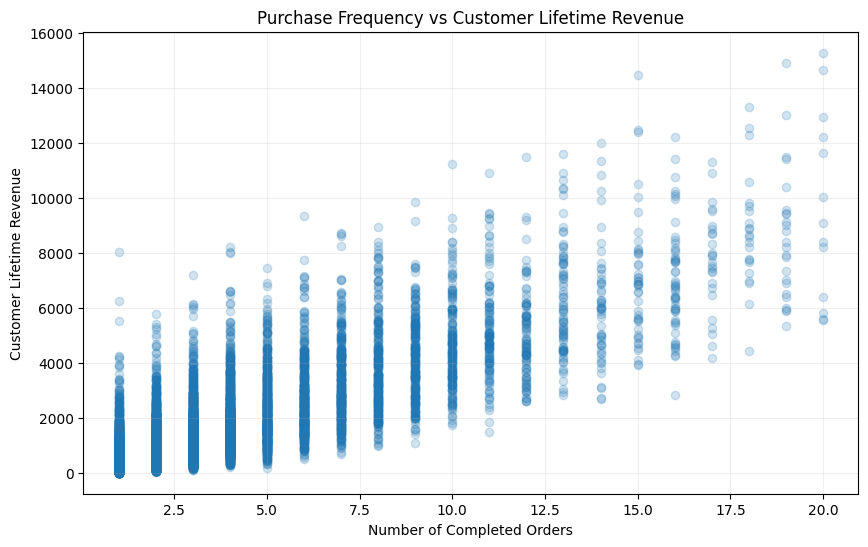

In [ ]:
plot_data = customer_behavior[
    customer_behavior['total_orders'] <= 20
]

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data['total_orders'],
    plot_data['total_revenue'],
    alpha=0.20
)

plt.title('Purchase Frequency vs Customer Lifetime Revenue')
plt.xlabel('Number of Completed Orders')
plt.ylabel('Customer Lifetime Revenue')

plt.grid(alpha=0.2)
plt.show()

In [ ]:
customer_behavior['customer_group'] = np.where(
    customer_behavior['total_orders'] == 1,
    'One-Time',
    'Repeat'
)

repeat_comparison = (
    customer_behavior
    .groupby('customer_group')
    .agg(
        customers=('customer_id', 'count'),
        avg_orders=('total_orders', 'mean'),
        avg_revenue=('total_revenue', 'mean'),
        median_revenue=('total_revenue', 'median'),
        avg_profit=('total_profit', 'mean')
    )
    .round(2)
)

repeat_comparison

,customers,avg_orders,avg_revenue,median_revenue,avg_profit
customer_group,,,,,
One-Time,3382,1.00,462.02,270.41,114.04
Repeat,7897,5.02,2284.41,1557.10,566.98


In [ ]:
refunded_returns = returns[
    returns['return_status'] == 'Refunded'
].copy()

product_returns = (
    refunded_returns
    .groupby('order_item_id', as_index=False)
    .agg(
        returned_units=('returned_quantity', 'sum'),
        refund_amount=('refund_amount', 'sum')
    )
)

In [ ]:
product_risk = sales.merge(
    product_returns,
    on='order_item_id',
    how='left'
)

product_risk['returned_units'] = (
    product_risk['returned_units'].fillna(0)
)

product_risk['refund_amount'] = (
    product_risk['refund_amount'].fillna(0)
)

In [ ]:
product_summary = (
    product_risk
    .groupby(
        ['product_id', 'product_name', 'category'],
        as_index=False
    )
    .agg(
        units_sold=('quantity', 'sum'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
        returned_units=('returned_units', 'sum'),
        refund_amount=('refund_amount', 'sum')
    )
)

product_summary['margin_pct'] = (
    product_summary['profit'] /
    product_summary['revenue'] * 100
)

product_summary['return_rate_pct'] = (
    product_summary['returned_units'] /
    product_summary['units_sold'] * 100
)

product_summary['refund_revenue_pct'] = (
    product_summary['refund_amount'] /
    product_summary['revenue'] * 100
)

In [ ]:
print("Products:", len(product_summary))

print(
    "Refund Amount:",
    round(product_summary['refund_amount'].sum(), 2)
)

print(
    "Returned Units:",
    int(product_summary['returned_units'].sum())
)

Products: 1500
Refund Amount: 862639.96
Returned Units: 5366


In [ ]:
risk_products = product_summary[
    product_summary['units_sold'] >= 50
].copy()

print("Products with at least 50 units sold:", len(risk_products))

print("\nMedian Margin:",
      round(risk_products['margin_pct'].median(), 2))

print("Median Return Rate:",
      round(risk_products['return_rate_pct'].median(), 2))

Products with at least 50 units sold: 807

Median Margin: 34.08
Median Return Rate: 3.57


In [ ]:
median_margin = risk_products['margin_pct'].median()
median_return = risk_products['return_rate_pct'].median()

risk_products['risk_segment'] = np.select(
    [
        (risk_products['margin_pct'] < median_margin) &
        (risk_products['return_rate_pct'] > median_return),

        (risk_products['margin_pct'] >= median_margin) &
        (risk_products['return_rate_pct'] > median_return),

        (risk_products['margin_pct'] < median_margin) &
        (risk_products['return_rate_pct'] <= median_return)
    ],
    [
        'High Return + Low Margin',
        'High Return',
        'Low Margin'
    ],
    default='Healthy'
)

In [ ]:
risk_products['risk_segment'].value_counts()

,count
risk_segment,
High Return,227
Low Margin,227
Healthy,177
High Return + Low Margin,176


In [ ]:
high_risk = (
    risk_products[
        risk_products['risk_segment'] == 'High Return + Low Margin'
    ]
    .sort_values(
        ['refund_amount', 'revenue'],
        ascending=False
    )
)

high_risk[
    [
        'product_id',
        'product_name',
        'category',
        'units_sold',
        'revenue',
        'margin_pct',
        'return_rate_pct',
        'refund_amount'
    ]
].head(10).round(2)

,product_id,product_name,category,units_sold,revenue,margin_pct,return_rate_pct,refund_amount
535,200536,Smart Home Product 0536,Electronics,947,370024.33,17.65,5.07,18842.22
168,200169,Headphones Product 0169,Electronics,499,454374.74,13.90,3.61,16532.67
390,200391,Headphones Product 0391,Electronics,418,205139.73,32.82,5.50,10941.87
516,200517,Smart Home Product 0517,Electronics,382,174749.78,13.77,5.24,9186.04
12,200013,Smartphones Product 0013,Electronics,168,184159.66,17.06,4.76,8291.48
1317,201318,Smart Home Product 1318,Electronics,233,173930.93,13.49,4.72,8044.81
37,200038,Cameras Product 0038,Electronics,85,69104.53,18.57,11.76,7811.25
1432,201433,Cameras Product 1433,Electronics,149,73017.26,22.62,9.40,7106.94
938,200939,Cameras Product 0939,Electronics,427,113655.47,13.48,5.85,6841.85
1056,201057,Smart Home Product 1057,Electronics,269,148234.76,14.51,4.46,6841.32


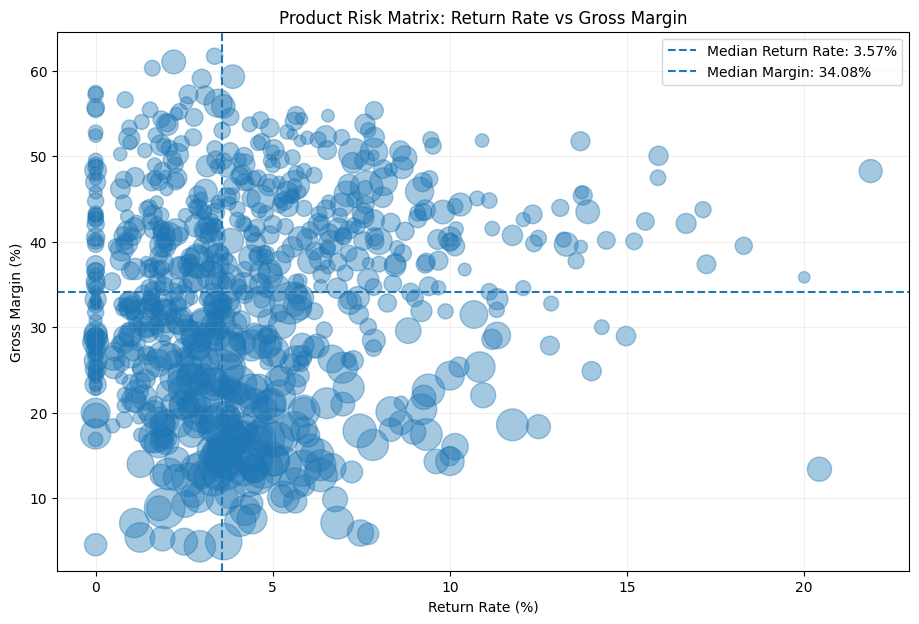

In [ ]:
plt.figure(figsize=(11, 7))

plt.scatter(
    risk_products['return_rate_pct'],
    risk_products['margin_pct'],
    s=np.sqrt(risk_products['revenue']) * 2,
    alpha=0.4
)

plt.axvline(
    median_return,
    linestyle='--',
    label=f'Median Return Rate: {median_return:.2f}%'
)

plt.axhline(
    median_margin,
    linestyle='--',
    label=f'Median Margin: {median_margin:.2f}%'
)

plt.title('Product Risk Matrix: Return Rate vs Gross Margin')
plt.xlabel('Return Rate (%)')
plt.ylabel('Gross Margin (%)')

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
return_detail = (
    refunded_returns
    .merge(
        order_items[['order_item_id', 'product_id']],
        on='order_item_id',
        how='left'
    )
    .merge(
        products[['product_id', 'category']],
        on='product_id',
        how='left'
    )
)

return_reason_category = (
    return_detail
    .groupby(
        ['return_reason', 'category'],
        as_index=False
    )
    .agg(
        return_records=('return_id', 'count'),
        returned_units=('returned_quantity', 'sum'),
        refund_amount=('refund_amount', 'sum')
    )
)

return_reason_category.sort_values(
    'refund_amount',
    ascending=False
).head(15).round(2)

,return_reason,category,return_records,returned_units,refund_amount
29,Wrong Product,Electronics,282,334,148346.95
16,Not as Expected,Electronics,248,314,145095.79
23,Poor Quality,Electronics,234,294,132249.84
9,Damaged,Electronics,252,296,125155.18
2,Changed Mind,Fashion,430,531,43391.02
24,Poor Quality,Fashion,421,502,40896.15
26,Size Issue,Fashion,424,522,40338.17
17,Not as Expected,Fashion,419,494,40333.61
13,Late Delivery,Home & Kitchen,135,168,19176.06
10,Damaged,Home & Kitchen,123,138,16348.56


In [ ]:
return_pivot = pd.pivot_table(
    return_reason_category,
    values='refund_amount',
    index='return_reason',
    columns='category',
    aggfunc='sum',
    fill_value=0
)

return_pivot.round(2)

category,Accessories,Beauty,Books,Electronics,Fashion,Home & Kitchen,Office,Sports
return_reason,,,,,,,,
Changed Mind,0.00,4317.74,541.47,0.00,43391.02,15468.43,3659.92,7477.75
Damaged,5217.58,4566.48,755.42,125155.18,0.00,16348.56,3673.13,0.00
Late Delivery,0.00,0.00,549.87,0.00,0.00,19176.06,0.00,0.00
Not as Expected,4946.45,3663.83,0.00,145095.79,40333.61,16286.71,3103.67,7357.88
Poor Quality,4785.10,2908.05,0.00,132249.84,40896.15,0.00,0.00,5048.57
Size Issue,0.00,0.00,0.00,0.00,40338.17,0.00,0.00,0.00
Wrong Product,5977.09,0.00,620.32,148346.95,0.00,0.00,3983.96,6399.21


In [ ]:
dominant_return_categories = (
    return_reason_category
    .sort_values('refund_amount', ascending=False)
    .groupby('return_reason')
    .first()
    .reset_index()
)

dominant_return_categories[
    [
        'return_reason',
        'category',
        'returned_units',
        'refund_amount'
    ]
].sort_values(
    'refund_amount',
    ascending=False
).round(2)

,return_reason,category,returned_units,refund_amount
6,Wrong Product,Electronics,334,148346.95
3,Not as Expected,Electronics,314,145095.79
4,Poor Quality,Electronics,294,132249.84
1,Damaged,Electronics,296,125155.18
0,Changed Mind,Fashion,531,43391.02
5,Size Issue,Fashion,522,40338.17
2,Late Delivery,Home & Kitchen,168,19176.06


In [ ]:
import pandas as pd
import numpy as np

customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
returns = pd.read_csv("returns.csv")

# Convert dates
orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
products["launch_date"] = pd.to_datetime(products["launch_date"])
payments["payment_date"] = pd.to_datetime(payments["payment_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)

Orders: (45000, 12)
Order Items: (92002, 11)


In [ ]:
print(orders["order_status"].value_counts())

order_status
Completed    43001
Cancelled     1554
Pending        445
Name: count, dtype: int64


In [ ]:
# Customer-level RFM table

completed_orders = orders[orders["order_status"] == "Completed"].copy()

# Frequency + last order date
rf = (
    completed_orders.groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max"),
        frequency=("order_id", "nunique")
    )
    .reset_index()
)

# Monetary value from completed order items
completed_items = (
    order_items
    .merge(
        completed_orders[["order_id", "customer_id"]],
        on="order_id",
        how="inner"
    )
)

monetary = (
    completed_items.groupby("customer_id")["revenue"]
    .sum()
    .reset_index(name="monetary")
)

rfm = rf.merge(monetary, on="customer_id", how="left")

# Reference date used in our analysis
reference_date = pd.Timestamp("2026-01-01")

rfm["last_order_date"] = pd.to_datetime(rfm["last_order_date"])
rfm["recency"] = (reference_date - rfm["last_order_date"]).dt.days

In [ ]:
# R: lower recency is better
rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# F: higher frequency is better
rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# M: higher monetary value is better
rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
def assign_rfm_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal"
    elif r >= 4 and f <= 3:
        return "Potential Loyalists"
    elif r <= 2 and f >= 4 and m >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost"
    else:
        return "Others"

rfm["rfm_segment"] = rfm.apply(assign_rfm_segment, axis=1)

In [ ]:
rfm_summary = (
    rfm.groupby("rfm_segment")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_frequency=("frequency", "mean"),
        avg_recency=("recency", "mean")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

rfm_summary

,rfm_segment,customers,revenue,avg_frequency,avg_recency
1,Champions,2340,10131294.73,9.034188,44.342308
3,Loyal,1293,2960504.71,5.383604,151.539830
4,Others,2487,2201457.84,2.230800,316.787294
2,Lost,2913,1558028.55,1.195331,640.430141
5,Potential Loyalists,1652,1417349.21,1.910412,54.705811
0,At Risk,594,1333866.42,4.569024,423.087542


In [ ]:
print("Total Customers:", rfm["customer_id"].nunique())
print("Total Revenue:", round(rfm["monetary"].sum(), 2))

Total Customers: 11279
Total Revenue: 19602501.46


In [ ]:
rfm_export = rfm[
    [
        "customer_id",
        "last_order_date",
        "recency",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
        "rfm_segment"
    ]
]

rfm_export.to_csv("customer_rfm.csv", index=False)

print(rfm_export.shape)
rfm_export.head()

(11279, 9)


,customer_id,last_order_date,recency,frequency,monetary,r_score,f_score,m_score,rfm_segment
0,100001,2025-11-25,37,25,19246.07,5,5,5,Champions
1,100002,2025-12-11,21,2,1410.32,5,2,4,Potential Loyalists
2,100004,2025-03-20,287,2,878.84,2,2,3,Lost
3,100005,2024-04-05,636,2,402.81,1,2,2,Lost
4,100006,2025-10-30,63,13,4349.85,4,5,5,Champions


In [ ]:
from google.colab import files
files.download("customer_rfm.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>